In [1]:
import pandas as pd
import numpy as np

---
#### **ASVI 계산**

In [2]:
SVI = pd.read_csv("./input/SVI.csv", index_col=0, parse_dates=True)
SVI = SVI.resample('ME').last()
SVI.tail()

,N_배당,N_배당금,N_배당_주제_1,N_배당_주제_2,G_배당,G_배당금
Date,,,,,,
2025-09-30,16.50536,14.79326,16.15301,21.78019,45,47
2025-10-31,17.97116,17.37903,18.52340,26.10960,57,58
2025-11-30,23.29223,17.02531,19.96179,26.46989,92,77
2025-12-31,24.09541,18.81653,21.53607,26.95812,100,85
2026-01-31,18.77434,18.25896,19.42720,24.20369,80,70


In [3]:
# 로그 차분
ln_SVI = np.log(SVI).diff()

In [4]:
import statsmodels.api as sm

# 월 정보
month = ln_SVI.index.month

# 월 더미 (1월 기준)
month_dummies = pd.get_dummies(month, prefix='M', drop_first=True)
month_dummies.index = ln_SVI.index

# 디자인 매트릭스
X = sm.add_constant(month_dummies).astype(float)

In [5]:
# 컬럼별로 회귀
ASVI = pd.DataFrame(index=ln_SVI.index, columns=ln_SVI.columns, dtype=float)

for col in ln_SVI.columns:
    y = ln_SVI[col].astype(float)

    # 결측 제거
    mask = y.notna()

    if mask.sum() <= X.shape[1]:
        continue  # 표본 부족하면 스킵

    model = sm.OLS(y.loc[mask], X.loc[mask]).fit()

    # 계절성 제거된 ASVI = 잔차
    ASVI.loc[mask, col] = model.resid

ASVI.tail()

,N_배당,N_배당금,N_배당_주제_1,N_배당_주제_2,G_배당,G_배당금
Date,,,,,,
2025-09-30,-0.241814,-0.038534,-0.099514,-0.095444,-0.092863,0.124073
2025-10-31,-0.102718,0.009462,-0.028020,0.077876,0.159391,0.124402
2025-11-30,0.287461,-0.079165,0.045949,-0.063468,0.363592,0.077630
2025-12-31,-0.583265,-0.277427,-0.395759,-0.394478,-0.079253,-0.212527
2026-01-31,0.168262,0.199828,0.198779,0.351444,-0.127880,-0.134676


In [6]:
round(ASVI.describe(), 6)

,N_배당,N_배당금,N_배당_주제_1,N_배당_주제_2,G_배당,G_배당금
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000
std,0.142606,0.155239,0.139950,0.147992,0.112839,0.154861
min,-0.583265,-0.562028,-0.501455,-0.394478,-0.247504,-0.564105
25%,-0.084064,-0.101375,-0.091456,-0.099042,-0.079979,-0.084453
50%,-0.002768,-0.012042,0.004085,-0.014403,-0.000788,0.001031
75%,0.067114,0.107261,0.089062,0.084653,0.067033,0.094677
max,0.425965,0.402524,0.389036,0.549589,0.365106,0.434174


In [7]:
ASVI.to_csv("./output/ASVI.csv")

---
#### **배당 포트폴리오 구성**

- 매년 6월 말에
- 수정 배당 수익률 = 결산 기준(전년도 12월말 기준) 수정 DPS / 6월 말 수정주가
- KOSPI 종목 수정 배당 수익률 기준으로 5분위 Breakpoint 계산
- Breakpoint에 따라 KOSPI+KOSDAQ 전체 종목을 5분위로 분류
- 5분위 포트폴리오 월간 수익률 계산

In [8]:
adj_dps      = pd.read_csv("./input/수정DPS.csv", index_col=0, parse_dates=True)
adj_close    = pd.read_csv("./input/수정종가.csv", index_col=0, parse_dates=True)
is_kospi_raw = pd.read_csv("./input/시장구분.csv", index_col=0, parse_dates=True)

C:\Users\kzhfi\AppData\Local\Temp\ipykernel_19388\2583205702.py:3: DtypeWarning: Columns (4,5,8,10,11,12,19,21,28,31,32,33,35,36,39,40,45,48,49,50,51,54,57,59,61,63,65,67,68,69,73,75,77,79,82,85,86,87,90,93,95,96,100,101,102,103,105,108,111,112,114,115,116,117,118,122,126,127,128,130,131,135,136,137,138,140,141,142,144,146,152,153,154,156,157,159,160,162,164,165,167,169,170,172,174,180,181,183,185,186,188,189,190,191,192,194,196,199,200,201,202,206,207,208,210,211,212,217,218,219,221,223,227,228,229,232,233,234,235,236,237,238,243,246,251,254,256,257,258,263,264,265,266,267,269,273,275,277,278,279,280,281,282,283,285,286,287,289,290,292,293,294,296,297,298,299,300,301,302,303,304,305,309,311,314,315,316,319,320,323,324,326,327,328,329,331,333,335,338,339,340,341,343,344,345,346,347,349,350,351,354,355,359,360,363,364,365,366,367,368,369,370,371,372,373,379,380,383,386,390,391,392,393,395,397,400,404,405,406,410,411,412,417,419,420,421,422,424,427,431,434,435,436,437,440,442,444,445,446

In [9]:
# adj_dps와 adj_close 컬럼 비교
diff_dpr_close = set(adj_dps.columns) - set(adj_close.columns)
diff_close_dpr = set(adj_close.columns) - set(adj_dps.columns)

print(f"adj_dps에만 있는 컬럼: {diff_dpr_close}")
print(f"adj_close에만 있는 컬럼: {diff_close_dpr}")

# 이름 변경
rename_dict = {
    'HD건설기계': 'HD현대건설기계',
    '라온로보틱스': '라온테크',
    '지아이에스': '네온테크',
    '스테이지원엔터': '엔에스이엔엠'
}

adj_dps = adj_dps.rename(columns=rename_dict)

# '덕양에너젠' 삭제
if '덕양에너젠' in adj_dps.columns:
    adj_dps = adj_dps.drop(columns=['덕양에너젠'])

# adj_dps와 adj_close 컬럼 비교
diff_dpr_close = set(adj_dps.columns) - set(adj_close.columns)
diff_close_dpr = set(adj_close.columns) - set(adj_dps.columns)

print(f"adj_dps에만 있는 컬럼: {diff_dpr_close}")
print(f"adj_close에만 있는 컬럼: {diff_close_dpr}")

adj_dps에만 있는 컬럼: {'지아이에스', 'HD건설기계', '덕양에너젠', '라온로보틱스', '스테이지원엔터'}
adj_close에만 있는 컬럼: {'HD현대건설기계', '엔에스이엔엠', '라온테크', '네온테크'}
adj_dps에만 있는 컬럼: set()
adj_close에만 있는 컬럼: set()


In [10]:
adj_dps_shifted   = adj_dps.resample('ME').last().shift(17).apply(pd.to_numeric, errors="coerce")
adj_close_monthly = adj_close.resample('ME').last()
is_kospi = (is_kospi_raw == 'KSE').astype(int).resample('ME').last()

In [11]:
div_yield   = adj_dps_shifted / adj_close_monthly
monthly_ret = adj_close_monthly.pct_change(fill_method=None)

---
---

In [12]:
# div_yield.loc[start_date]에서 nan은 nan, 0 이하인 값은 0, 나머지는 분위수에 따라 1~5 할당
def assign_quintile(value, breakpoints):
    if pd.isna(value):
        return np.nan
    elif value <= 0:
        return 0
    elif value <= breakpoints[0.2]:
        return 1
    elif value <= breakpoints[0.4]:
        return 2
    elif value <= breakpoints[0.6]:
        return 3
    elif value <= breakpoints[0.8]:
        return 4
    else:
        return 5

In [13]:
# 1) 원하는 연도 범위
start_year = 2008
end_year = 2026

# 2) 매년 6월 30일 생성
selection_dates = pd.to_datetime([
    f"{year}-06-30" for year in range(start_year, end_year + 1)
])

selection_dates

DatetimeIndex(['2008-06-30', '2009-06-30', '2010-06-30', '2011-06-30',
               '2012-06-30', '2013-06-30', '2014-06-30', '2015-06-30',
               '2016-06-30', '2017-06-30', '2018-06-30', '2019-06-30',
               '2020-06-30', '2021-06-30', '2022-06-30', '2023-06-30',
               '2024-06-30', '2025-06-30', '2026-06-30'],
              dtype='datetime64[ns]', freq=None)

In [14]:
initial_nav  = pd.Series(1.0, index=[0, 1, 2, 3, 4, 5])
quintile_nav = pd.DataFrame([initial_nav], index=[selection_dates[0]], columns=[0, 1, 2, 3, 4, 5])

for i in range(0, len(selection_dates) - 1):
    start_date = selection_dates[i]
    end_date   = selection_dates[i + 1]
    start_date, end_date

    # div_yield에서 값이 0인 항목 제거
    div_yield_filtered = div_yield.loc[start_date][div_yield.loc[start_date] > 0]

    # div_yield_filtered에서 is_kospi.loc[start_date] == 1인 항목만 선택
    div_yield_filtered_kospi = div_yield_filtered[is_kospi.loc[start_date][div_yield_filtered.index] == 1]

    # div_yield_filtered_kospi로 5분위 breakpoints 계산
    breakpoints = div_yield_filtered_kospi.quantile([0.2, 0.4, 0.6, 0.8])

    quintile_series = div_yield.loc[start_date].apply(assign_quintile, args=(breakpoints,))

    # quintile_series의 nan 중에서 adj_close_monthly.loc[start_date]가 nan이 아닌 항목을 0으로 대체
    quintile_series = quintile_series.where(
        ~quintile_series.isna() | adj_close_monthly.loc[start_date].isna(),
        0
    )

    curr_nav = adj_close_monthly[start_date:end_date].ffill() / adj_close_monthly.loc[start_date]
    # curr_nav = adj_close.asfreq('D', method='ffill')[start_date:end_date].ffill() / adj_close.asfreq('D', method='ffill').loc[start_date]

    # quintile_series의 각 값에 해당하는 종목들의 curr_nav 평균 계산
    quintile_curr_nav = pd.DataFrame(index=curr_nav.index, columns=[0, 1, 2, 3, 4, 5], dtype=float)

    for quintile in [0, 1, 2, 3, 4, 5]:
        selected_stocks = quintile_series[quintile_series == quintile].index
        quintile_curr_nav[quintile] = curr_nav[selected_stocks].mean(axis=1)

    quintile_curr_nav = quintile_curr_nav * initial_nav

    quintile_nav = pd.concat([quintile_nav, quintile_curr_nav[1:]])

    initial_nav = quintile_curr_nav.iloc[-1]

quintile_nav.tail()

,0,1,2,3,4,5
2025-09-30,14.294040,2.354025,3.728908,4.837286,4.861694,5.267550
2025-10-31,14.438797,2.499302,3.770083,4.846478,4.814725,5.274759
2025-11-30,14.276045,2.429271,3.734430,4.878969,4.867807,5.422989
2025-12-31,14.842092,2.483703,3.786608,4.946040,4.948221,5.484501
2026-01-31,15.376607,2.688825,3.911438,5.120043,5.072466,5.595568


In [15]:
breakpoints

0.2    0.010865
0.4    0.020919
0.6    0.030675
0.8    0.042520
Name: 2025-06-30 00:00:00, dtype: float64

In [16]:
# (quintile_nav.loc['2014':] / quintile_nav.loc['2014-01-01']).plot()

In [17]:
quintile_ret = quintile_nav.pct_change(fill_method=None)

In [18]:
quintile_ret.to_csv('div_port_quintile_ret.csv')

In [19]:
# ls_portfolio = quintile_ret[5] - quintile_ret[1]
ls_portfolio = quintile_ret[5]

<Axes: >

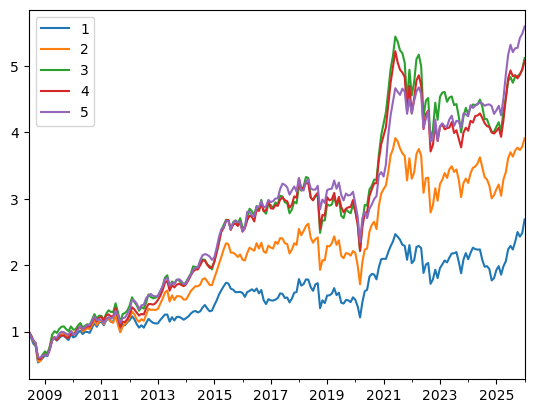

In [234]:
quintile_nav.drop(columns=0).plot()

<Axes: >

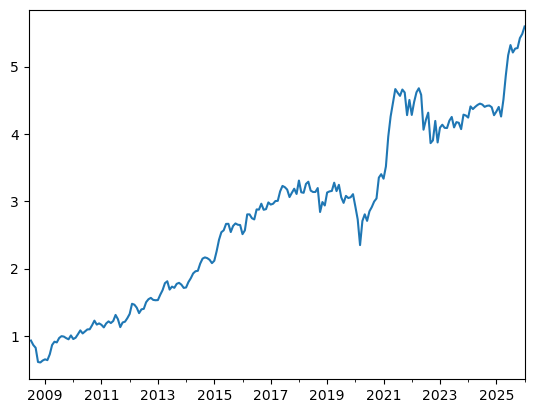

In [20]:
(ls_portfolio + 1).cumprod().plot()

---
#### **Abnomal Return**

In [21]:
import pandas as pd

factor = pd.read_csv("./input/Factor.csv", index_col=0, parse_dates=True)
factor.tail()

,SMB,HML,MOM,KOSPI,RF
Date,,,,,
2025-10-31,92.91,1824.08,227.66,4107.50,2.55
2025-11-30,93.30,1878.44,228.41,3926.59,2.80
2025-12-31,91.35,1927.96,238.29,4214.17,2.81
2026-01-31,80.12,1888.84,272.24,5224.36,2.73
2026-02-05,81.24,1985.71,270.42,5163.57,2.75


In [22]:
factor.drop(columns=['RF'])
factor

,SMB,HML,MOM,KOSPI,RF
Date,,,,,
2005-01-31,101.52,246.35,76.26,932.70,3.57
2005-02-28,105.00,272.17,84.27,1011.36,3.55
2005-03-31,101.26,279.95,81.83,965.68,3.54
2005-04-30,102.06,294.28,83.79,911.30,3.48
2005-05-31,106.49,273.72,82.26,970.21,3.52
...,...,...,...,...,...
2025-10-31,92.91,1824.08,227.66,4107.50,2.55
2025-11-30,93.30,1878.44,228.41,3926.59,2.80
2025-12-31,91.35,1927.96,238.29,4214.17,2.81


In [23]:
rf = (1 + factor['RF'] / 100) ** (1/12) - 1
factor.drop(columns=['RF'])
factor = factor.pct_change(fill_method=None)
factor['RF'] = rf
factor['MKT'] = factor['KOSPI'] - factor['RF']

In [24]:
factor.tail()

,SMB,HML,MOM,KOSPI,RF,MKT
Date,,,,,,
2025-10-31,-0.148630,-0.047836,0.012542,0.199410,0.002101,0.197310
2025-11-30,0.004198,0.029801,0.003294,-0.044044,0.002304,-0.046348
2025-12-31,-0.020900,0.026362,0.043256,0.073239,0.002312,0.070927
2026-01-31,-0.122934,-0.020291,0.142473,0.239713,0.002247,0.237466
2026-02-05,0.013979,0.051285,-0.006685,-0.011636,0.002263,-0.013899


In [25]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS

# 0) 준비: LS 초과수익(월말)과 요인 정렬
ls_excess = (ls_portfolio - factor['RF']).dropna()

F = factor.loc[ls_excess.index, ['MKT', 'SMB', 'HML', 'MOM']].copy()
data = pd.concat([ls_excess.rename('y'), F], axis=1).dropna()

y = data['y']
X = sm.add_constant(data[['MKT', 'SMB', 'HML', 'MOM']])

# 1) Rolling 회귀 (예: 60개월)
W = 60  # 36/48/60/84 등으로 강건성 체크 가능
rol = RollingOLS(endog=y, exog=X, window=W).fit()

# 2) (중요) 미래정보유출 방지 버전의 Carhart-4 adjusted return
#    t 시점 잔차 = y_t - (alpha_{t-1} + beta_{t-1}'F_t)
params_lag = rol.params.shift(1)  # 계수는 t-1까지 정보로 추정된 값 사용

fitted_lag = (X * params_lag).sum(axis=1)
carhart4_adj_ret = (y - fitted_lag).dropna()

# --- 선택: "윈도우에 t를 포함한" 일반 롤링 잔차(엄밀히는 look-ahead 성격)
# fitted_in = (X * rol.params).sum(axis=1)
# carhart4_adj_ret_rolling_inwindow = (y - fitted_in).dropna()

print(carhart4_adj_ret.tail())


2025-09-30   -0.014600
2025-10-31   -0.032701
2025-11-30    0.043386
2025-12-31   -0.031130
2026-01-31   -0.038900
dtype: float64


<Axes: >

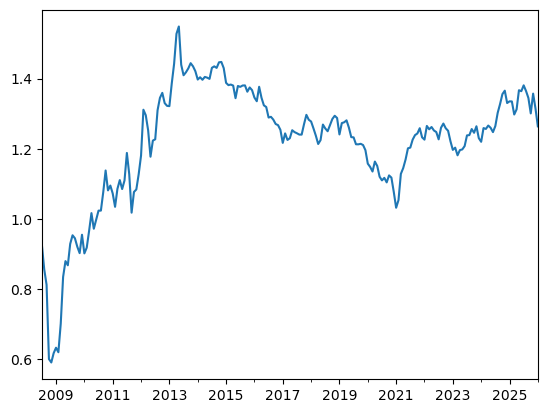

In [26]:
(carhart4_adj_ret + 1).cumprod().plot()

---
#### **투자주체별 순매수강도 계산**

In [27]:
# 투자주체별 순매수대금 데이터 불러오기
indiv_net_buy       = pd.read_csv("./input/개인순매수대금.csv", index_col=0, parse_dates=True)
foreigner_net_buy   = pd.read_csv("./input/외국인순매수대금.csv", index_col=0, parse_dates=True)
institution_net_buy = pd.read_csv("./input/기관순매수대금.csv", index_col=0, parse_dates=True)

indiv_net_buy       = indiv_net_buy.resample('ME').sum()
foreigner_net_buy   = foreigner_net_buy.resample('ME').sum()
institution_net_buy = institution_net_buy.resample('ME').sum()

# 시가총액 데이터 불러오기
market_cap = pd.read_csv("./input/시가총액.csv", index_col=0, parse_dates=True)
market_cap = market_cap.resample('ME').last()

In [28]:
# 월간 순매수강도 계산
indiv_buy_strength       = indiv_net_buy / market_cap.shift(1)
foreigner_buy_strength   = foreigner_net_buy / market_cap.shift(1)
institution_buy_strength = institution_net_buy / market_cap.shift(1)

In [29]:
import pandas as pd
import numpy as np

# 결과 저장용: 각 날짜별(월말) 분위 포트폴리오 순매수강도
# (t월 net_buy) / (t-1월 mktcap)
quintile_indiv_bs       = pd.DataFrame(index=market_cap.index, columns=[0,1,2,3,4,5], dtype=float)
quintile_foreigner_bs   = pd.DataFrame(index=market_cap.index, columns=[0,1,2,3,4,5], dtype=float)
quintile_institution_bs = pd.DataFrame(index=market_cap.index, columns=[0,1,2,3,4,5], dtype=float)

for i in range(0, len(selection_dates) - 1):
    start_date = selection_dates[i]
    end_date   = selection_dates[i + 1]

    # 1) breakpoints: KOSPI & div_yield>0 종목으로 계산
    div_yield_filtered = div_yield.loc[start_date][div_yield.loc[start_date] > 0]
    div_yield_filtered_kospi = div_yield_filtered[
        is_kospi.loc[start_date][div_yield_filtered.index] == 1
    ]
    breakpoints = div_yield_filtered_kospi.quantile([0.2, 0.4, 0.6, 0.8])

    # 2) 전체 종목에 분위 할당 (0은 div_yield<=0, NaN은 그대로)
    quintile_series = div_yield.loc[start_date].apply(assign_quintile, args=(breakpoints,))

    # (선택) 시장 데이터가 존재하는데 quintile이 NaN인 애들은 0으로
    quintile_series = quintile_series.where(
        ~quintile_series.isna() | market_cap.loc[start_date].isna(),
        0
    )

    # 3) 이 구간의 분자(당월 순매수) / 분모(전월 시총)
    #    ※ 인덱스 정렬을 위해 동일한 기간으로 슬라이스
    curr_indiv_nb       = indiv_net_buy.loc[start_date:end_date]
    curr_foreigner_nb   = foreigner_net_buy.loc[start_date:end_date]
    curr_institution_nb = institution_net_buy.loc[start_date:end_date]

    curr_mktcap_lag = market_cap.shift(1).loc[start_date:end_date]  # t-1 시총

    # 4) 분위별 포트폴리오 순매수강도 계산: sum(net_buy) / sum(mktcap_lag)
    for q in [0,1,2,3,4,5]:
        stocks = quintile_series[quintile_series == q].index
        if len(stocks) == 0:
            continue

        # 종목이 curr_mktcap_lag/순매수 데이터에 실제로 존재하는지 교집합 처리(안전)
        stocks = stocks.intersection(curr_mktcap_lag.columns)

        # 분자
        nb_indiv_q       = curr_indiv_nb[stocks].sum(axis=1)
        nb_foreigner_q   = curr_foreigner_nb[stocks].sum(axis=1)
        nb_institution_q = curr_institution_nb[stocks].sum(axis=1)

        # 분모 (전월 시총 합)
        cap_q = curr_mktcap_lag[stocks].sum(axis=1)

        # 0으로 나누기 방지
        cap_q = cap_q.replace(0, np.nan)

        quintile_indiv_bs.loc[cap_q.index, q]       = nb_indiv_q / cap_q
        quintile_foreigner_bs.loc[cap_q.index, q]   = nb_foreigner_q / cap_q
        quintile_institution_bs.loc[cap_q.index, q] = nb_institution_q / cap_q

# 보기
quintile_indiv_bs.tail(), quintile_foreigner_bs.tail(), quintile_institution_bs.tail()

(                   0         1         2         3         4         5
 Date                                                                  
 2025-09-30  0.161407 -0.394086 -0.300136 -1.149137  0.108164  0.143500
 2025-10-31 -0.164470  0.172859 -0.239084 -0.828176  0.103576  0.206223
 2025-11-30  0.068974  0.673678 -0.113520  0.134424 -0.248227 -0.309320
 2025-12-31  0.087760 -0.354348 -0.186893 -0.398359 -0.106425 -0.326699
 2026-01-31 -0.164494 -0.298941 -0.092049  0.148094 -0.404140  0.317141,
                    0         1         2         3         4         5
 Date                                                                  
 2025-09-30 -0.081039  0.237363  0.188707  0.799043  0.001676 -0.099835
 2025-10-31  0.154380 -0.398182  0.231004  0.938444  0.005819 -0.151409
 2025-11-30 -0.129967 -0.870619  0.050529 -0.291611 -0.020572  0.026232
 2025-12-31 -0.108915  0.240979 -0.023659  0.130916  0.127980  0.136075
 2026-01-31  0.349808  0.182703  0.064196 -0.316184  0.388794 -

In [30]:
# 상대 순매수강도 계산
rel_quintile_indiv_bs       = quintile_indiv_bs[5] - quintile_indiv_bs[1]
rel_quintile_foreigner_bs   = quintile_foreigner_bs[5] - quintile_foreigner_bs[1]
rel_quintile_institution_bs = quintile_institution_bs[5] - quintile_institution_bs[1]
rel_quintile_indiv_bs.tail(), rel_quintile_foreigner_bs.tail(), rel_quintile_institution_bs.tail()

(Date
 2025-09-30    0.537586
 2025-10-31    0.033364
 2025-11-30   -0.982998
 2025-12-31    0.027649
 2026-01-31    0.616082
 Freq: ME, dtype: float64,
 Date
 2025-09-30   -0.337198
 2025-10-31    0.246773
 2025-11-30    0.896851
 2025-12-31   -0.104904
 2026-01-31   -0.529990
 Freq: ME, dtype: float64,
 Date
 2025-09-30   -0.255504
 2025-10-31   -0.329288
 2025-11-30    0.051732
 2025-12-31    0.097995
 2026-01-31   -0.108242
 Freq: ME, dtype: float64)

---
#### **회귀분석 데이터 최종 정리**

In [41]:
flow_indiv_ls = rel_quintile_indiv_bs.copy().rename('flow_indiv_ls')
flow_for_ls   = rel_quintile_foreigner_bs.copy().rename('flow_for_ls')
flow_inst_ls  = rel_quintile_institution_bs.copy().rename('flow_inst_ls')

In [42]:
ASVI

,N_배당,N_배당금,N_배당_주제_1,N_배당_주제_2,G_배당,G_배당금
Date,,,,,,
2016-01-31,NaN,NaN,NaN,NaN,NaN,NaN
2016-02-29,0.047916,-0.021650,0.018432,0.041270,-0.018028,0.012939
2016-03-31,0.060323,0.188476,0.119619,0.061297,0.129771,0.212743
2016-04-30,-0.096099,-0.207714,-0.193599,-0.110411,-0.247504,-0.564105
2016-05-31,0.020598,-0.082257,-0.012175,-0.118411,0.006707,0.051212
...,...,...,...,...,...,...
2025-09-30,-0.241814,-0.038534,-0.099514,-0.095444,-0.092863,0.124073
2025-10-31,-0.102718,0.009462,-0.028020,0.077876,0.159391,0.124402
2025-11-30,0.287461,-0.079165,0.045949,-0.063468,0.363592,0.077630


In [53]:
# Controls

vkospi = pd.read_csv("./input/VKOSPI.csv", index_col=0, parse_dates=True)
vkospi = vkospi.iloc[:, 0].rename('vkospi')
vkospi = vkospi.resample('ME').last()

term_spread_raw = pd.read_csv("./input/기간스프레드.csv", index_col=0, parse_dates=True)
term_spread_raw = term_spread_raw.resample('ME').last()
term_spread = (term_spread_raw["국고10년"] - term_spread_raw["국고3년"]) / 100

In [54]:
# main vars
x = ASVI['N_배당_주제_1'].rename('asvi').copy()
y = carhart4_adj_ret.rename('adj_ret').copy()

# y_{t+1} (선행 버전도 "그대로" 포함)
y_fwd1 = y.shift(-1).rename('adj_ret_fwd1')

# controls
term_spread_s = term_spread.rename('term_spread').copy()
vkospi_s      = vkospi.rename('vkospi').copy()
rf_s          = rf.rename('rf').copy()

flow_indiv_ls = rel_quintile_indiv_bs.copy().rename('flow_indiv_ls')
flow_for_ls   = rel_quintile_foreigner_bs.copy().rename('flow_for_ls')
flow_inst_ls  = rel_quintile_institution_bs.copy().rename('flow_inst_ls')

# 회귀용 df (원본 y, 선행 y, x, 컨트롤 전부 포함)
reg_df = pd.concat(
    [
        x,
        y,
        y_fwd1,
        term_spread_s,
        vkospi_s,
        rf_s,
        flow_indiv_ls,
        flow_for_ls,
        flow_inst_ls
    ],
    axis=1
)

# (선택) 결측 제거: 회귀에 넣을 때 보통 필요
reg_df_dropna = reg_df.dropna()


In [55]:
reg_df_dropna.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 119 entries, 2016-02-29 to 2025-12-31
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   asvi           119 non-null    float64
 1   adj_ret        119 non-null    float64
 2   adj_ret_fwd1   119 non-null    float64
 3   term_spread    119 non-null    float64
 4   vkospi         119 non-null    float64
 5   rf             119 non-null    float64
 6   flow_indiv_ls  119 non-null    float64
 7   flow_for_ls    119 non-null    float64
 8   flow_inst_ls   119 non-null    float64
dtypes: float64(9)
memory usage: 9.3 KB


In [56]:
reg_df_dropna.describe()

,asvi,adj_ret,adj_ret_fwd1,term_spread,vkospi,rf,flow_indiv_ls,flow_for_ls,flow_inst_ls
count,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000
mean,-0.001670,-0.000017,-0.000278,0.003220,18.398655,0.001702,-0.004112,-0.057209,0.047919
std,0.139336,0.019072,0.019390,0.002228,6.166363,0.000844,0.423123,0.379980,0.260554
min,-0.501455,-0.041944,-0.041944,-0.000900,10.640000,0.000523,-1.452704,-1.281125,-0.631980
25%,-0.094142,-0.011470,-0.011620,0.001375,14.140000,0.001147,-0.275341,-0.298498,-0.106254
50%,0.003537,-0.002560,-0.002560,0.003150,17.260000,0.001365,0.027649,-0.087232,0.062647
75%,0.086237,0.012423,0.012423,0.004760,20.755000,0.002389,0.282898,0.170495,0.185747
max,0.389036,0.071026,0.071026,0.009870,48.550000,0.003298,1.086666,1.272846,0.723595


In [57]:
reg_df_dropna.tail()

,asvi,adj_ret,adj_ret_fwd1,term_spread,vkospi,rf,flow_indiv_ls,flow_for_ls,flow_inst_ls
2025-08-31,-0.139538,-0.011715,-0.014600,0.00389,19.52,0.002084,-0.127903,0.072040,0.017415
2025-09-30,-0.099514,-0.014600,-0.032701,0.00369,20.62,0.002117,0.537586,-0.337198,-0.255504
2025-10-31,-0.028020,-0.032701,0.043386,0.00345,30.40,0.002101,0.033364,0.246773,-0.329288
2025-11-30,0.045949,0.043386,-0.031130,0.00353,30.24,0.002304,-0.982998,0.896851,0.051732
2025-12-31,-0.395759,-0.031130,-0.038900,0.00432,28.85,0.002312,0.027649,-0.104904,0.097995


---
#### **최종 실증분석**

In [80]:
# =========================
# Block B (Table 1): Predictive regression
# AR_{t+1} on ASVI_t + controls
# =========================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display

# ---------- settings ----------
df = reg_df_dropna.copy().sort_index()
NW_LAGS = 4

# ---------- helpers ----------
def hac_ols(Y, X, lags=4):
    X = sm.add_constant(X, has_constant='add')
    return sm.OLS(Y, X).fit(
        cov_type='HAC',
        cov_kwds={'maxlags': lags, 'use_correction': True}
    )

def star(p):
    return '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else ''))

def fmt_coef(coef, p, nd=4):
    return f"{coef:.{nd}f}{star(p)}"

def fmt_t(t, nd=2):
    return f"({t:.{nd}f})"

def make_paper_table(models, colnames, var_order, nd_coef=4, nd_t=2):
    """
    Paper-style table:
    For each variable: coefficient row + t-stat row beneath.
    Adds N and R2 at bottom.
    """
    out_rows = []
    idx = []

    for v in var_order:
        # coef row
        row_coef = []
        row_t = []
        for res in models:
            if v in res.params.index:
                row_coef.append(fmt_coef(res.params[v], res.pvalues[v], nd=nd_coef))
                row_t.append(fmt_t(res.tvalues[v], nd=nd_t))
            else:
                row_coef.append("")
                row_t.append("")
        out_rows.append(row_coef); idx.append(v)
        out_rows.append(row_t);    idx.append("")

    # add summary rows
    out_rows.append([f"{int(res.nobs)}" for res in models]); idx.append("N")
    out_rows.append([f"{res.rsquared:.3f}" for res in models]); idx.append("$R^2$")

    tab = pd.DataFrame(out_rows, index=idx, columns=colnames)
    return tab

# ---------- Block B models ----------

def hac_ols_on_df(Y, X, lags=4):
    tmp = pd.concat([Y.rename('Y'), X], axis=1).dropna()
    res = sm.OLS(tmp['Y'], sm.add_constant(tmp[X.columns], has_constant='add')).fit(
        cov_type='HAC',
        cov_kwds={'maxlags': lags, 'use_correction': True}
    )
    return res, tmp.index

# 종속변수: shift(-1) 사용
Y1 = df['adj_ret'].shift(-1)
# Y1 = temp['spread_ret'].shift(-1)

# Spec (1)
res_B1, idx1 = hac_ols_on_df(Y1, df[['asvi']], lags=NW_LAGS)

# Spec (2)
res_B2, idx2 = hac_ols_on_df(Y1, df[['asvi','term_spread']], lags=NW_LAGS)

# Spec (3)
res_B3, idx3 = hac_ols_on_df(Y1, df[['asvi','term_spread','vkospi']], lags=NW_LAGS)

# Spec (4)
res_B4, idx4 = hac_ols_on_df(
    Y1,
    df[['asvi','term_spread','vkospi','flow_indiv_ls','flow_for_ls','flow_inst_ls']],
    lags=NW_LAGS
)

print(len(idx1), len(idx2), len(idx3), len(idx4))

models_B = [res_B1, res_B2, res_B3, res_B4]
colnames_B = ["(1) ASVI", "(2) +Term", "(3) +Vol", "(4) +Flows"]
var_order_B = ['asvi','term_spread','vkospi','flow_indiv_ls','flow_for_ls','flow_inst_ls','const']

table_B = make_paper_table(models_B, colnames_B, var_order_B, nd_coef=4, nd_t=2)

print("Table 1. Predictive regression of $AR^{LS}_{t+1}$ on $ASVI_t$ (HAC-NW)")
display(table_B)

118 118 118 118
Table 1. Predictive regression of $AR^{LS}_{t+1}$ on $ASVI_t$ (HAC-NW)


,(1) ASVI,(2) +Term,(3) +Vol,(4) +Flows
asvi,-0.0387**,-0.0393**,-0.0401***,-0.0353**
,(-2.32),(-2.45),(-2.66),(-2.31)
term_spread,,1.5042,1.3524,0.9320
,,(1.50),(1.34),(0.95)
vkospi,,,0.0003,0.0002
,,,(1.08),(0.70)
flow_indiv_ls,,,,-0.0257
,,,,(-0.96)
flow_for_ls,,,,-0.0129
,,,,(-0.49)


**Block B. 메인 예측회귀 (Table 1)**

- **목적**: 배당 관심/심리 쇼크(ASVI)가 **다음 달** 배당 롱숏 포트폴리오의 요인조정 비정상수익을 예측하는지 검정.
- **종속변수**: $AR^{LS}_{t+1}$ (`adj_ret_fwd1`)  
  - $AR^{LS}_t$는 Carhart-4 요인에 대해 (미래정보유출 방지형) rolling 방식으로 조정한 **비정상수익(잔차)**.
- **핵심 설명변수**: $ASVI_t$ (`asvi`)  
  - $\Delta \ln(SVI_t)$에서 월 더미로 계절성을 제거한 잔차.

**회귀식**
$$
AR^{LS}_{t+1}=\alpha+\beta ASVI_t+\gamma_1 TermSpread_t+\gamma_2 VKOSPI_t+\varepsilon_{t+1}.
$$

- $TermSpread_t$ = 국고 10년 − 국고 3년 (`term_spread`)
- $VKOSPI_t$ = 변동성 지수 레벨 (`vkospi`)
- **rf(CD91) 제외**: 이미 초과수익($R^{LS}-RF$) 및 Carhart 조정 단계에 사용되므로, 예측회귀의 통제에서 중복될 수 있어 제외.

**추정/표준오차**
- OLS 추정
- 표준오차: Newey–West HAC, lag = 4 (월간 자료 기준)

**해석 포인트**
- $\hat\beta<0$이면: **ASVI 상승(관심/수요 쇼크) 이후** 다음 달 비정상수익이 하락(되돌림)하는 패턴과 일치.
- Column (1)→(3)에서 $\beta$의 **부호와 크기 안정성**이 중요(통제 추가에도 유지되는지).
- Column (4) (+Flows)는 **부분 매개/채널** 점검용(본문 또는 부록 선택).

---

**Block B (Table 1). 예측회귀: $AR^{LS}_{t+1}$ on $ASVI_t$ (HAC–NW, lag=4)**

- 회귀식
  - $AR^{LS}_{t+1}=\alpha+\beta ASVI_t+\gamma_1 TermSpread_t+\gamma_2 VKOSPI_t+\varepsilon_{t+1}$
  - Column (4)는 추가로 $Flow^{g,LS}_t$ (개인/외국인/기관)를 포함
- 표본 및 추정
  - 월말 자료, $N=119$
  - 표준오차: Newey–West HAC (lag=4), 유의수준 표기: *** (1%), ** (5%), * (10%)
  - rf(CD91)는 이미 초과수익 및 Carhart 조정에 사용되어 예측회귀 통제에서 제외

- 핵심 결과(ASVI 계수 $\hat\beta$)
  - (1) ASVI only: $\hat\beta=-0.0345^*$, $t=-1.92$, $R^2=0.052$
  - (2) +Term: $\hat\beta=-0.0346^{**}$, $t=-1.97$, $R^2=0.070$
  - (3) +Vol: $\hat\beta=-0.0347^{**}$, $t=-2.10$, $R^2=0.083$
  - (4) +Flows: $\hat\beta=-0.0303^{**}$, $t=-1.99$, $R^2=0.106$

- 해석(개조식)
  - 모든 사양에서 $\hat\beta<0$이며, 통제변수(금리기간스프레드, VKOSPI) 추가 후에도 크기·부호가 크게 변하지 않음
  - Column (4)에서 $\hat\beta$의 절대값이 $0.0347 \rightarrow 0.0303$으로 감소하나, flows 계수는 유의하지 않아 “완전 매개” 주장보다는 “부분적 채널 시사” 수준으로 서술하는 것이 안전
  - 통제변수 자체(예: term_spread, vkospi)는 통계적으로 강한 설명력은 크지 않지만, $\beta$의 강건성을 보여주는 역할


---

In [81]:
# =========================
# Block C (Figure 1 + Table): Local projections
# AR_{t+h} on ASVI_t + controls
# =========================

df = reg_df_dropna.copy().sort_index()
# df = temp.copy().sort_index()
NW_LAGS = 4

# ---- settings ----
H = 6
controls_C = ['term_spread','vkospi']  # rf(CD91) 제외
# controls_C = []

# ---- estimate betas over horizons ----
rows = []
betas = []
ses = []
hs = []

for h in range(H+1):
    Y_h = df['adj_ret'].shift(-h)  # AR_{t+h}
    # Y_h = df['spread_ret'].shift(-h)  # AR_{t+h}
    tmp = pd.concat([Y_h.rename('Y'), df[['asvi'] + controls_C]], axis=1).dropna()

    res = hac_ols(tmp['Y'], tmp[['asvi'] + controls_C], lags=NW_LAGS)

    hs.append(h)
    betas.append(res.params['asvi'])
    ses.append(res.bse['asvi'])

    rows.append({
        'horizon(h)': h,
        'beta_h (ASVI)': float(res.params['asvi']),
        't(z)': float(res.tvalues['asvi']),
        'p': float(res.pvalues['asvi']),
        'R2': float(res.rsquared),
        'N': int(res.nobs),
    })

tbl_C = pd.DataFrame(rows).set_index('horizon(h)')
print("Table (Block C). Local projection: $AR^{LS}_{t+h}$ on $ASVI_t$ (HAC-NW)")
display(tbl_C[['beta_h (ASVI)','t(z)','p','R2','N']].round({'beta_h (ASVI)':6,'t(z)':3,'p':3,'R2':3}))

# ---- plot with 95% CI ----
betas = np.array(betas)
ses = np.array(ses)
ci_lo = betas - 1.96 * ses
ci_hi = betas + 1.96 * ses

# plt.figure(figsize=(8,4.5))
# plt.plot(hs, betas, marker='o', label=r'$\hat{\beta}_h$ (ASVI)')
# plt.fill_between(hs, ci_lo, ci_hi, alpha=0.2, label='95% CI')
# plt.axhline(0, color='black', linewidth=1)
# plt.xticks(hs)
# plt.xlabel('Horizon $h$ (months)')
# plt.ylabel(r'Coefficient on ASVI ($\beta_h$)')
# plt.title(r'Figure 1. Local projection of $AR^{LS}_{t+h}$ on $ASVI_t$ (controls: term spread, VKOSPI)')
# plt.legend()
# plt.tight_layout()
# plt.show()

# ---- optional: "main-text horizons only" (e.g., 0,1,2,4) ----
main_h = [0,1,2,4]
tbl_C_main = tbl_C.loc[main_h, ['beta_h (ASVI)','t(z)','p','R2','N']]
print("\n[Main-text subset] horizons h in {0,1,2,4}")
display(tbl_C_main.round({'beta_h (ASVI)':6,'t(z)':3,'p':3,'R2':3}))


Table (Block C). Local projection: $AR^{LS}_{t+h}$ on $ASVI_t$ (HAC-NW)


,beta_h (ASVI),t(z),p,R2,N
horizon(h),,,,,
0,0.024315,1.453,0.146,0.055,119
1,-0.040117,-2.660,0.008,0.113,118
2,0.003258,0.310,0.757,0.016,117
3,-0.000013,-0.001,0.999,0.033,116
4,-0.016175,-1.646,0.100,0.051,115
5,-0.010281,-0.909,0.363,0.035,114
6,0.013597,1.383,0.167,0.035,113



[Main-text subset] horizons h in {0,1,2,4}


,beta_h (ASVI),t(z),p,R2,N
horizon(h),,,,,
0,0.024315,1.453,0.146,0.055,119
1,-0.040117,-2.660,0.008,0.113,118
2,0.003258,0.310,0.757,0.016,117
4,-0.016175,-1.646,0.100,0.051,115


**Block C. Local Projection (Figure 1)**

- **목적**: ASVI 쇼크 이후 $AR^{LS}_{t+h}$가 시간에 따라 어떻게 반응하는지(동월/익월/중기) 확인.
- **주의**: 여러 지평 $h$를 동시에 추정하므로, 개별 $h$의 유의성 해석은 과해석 위험(다중검정). 본문에서는 **핵심 지평(예: $h=1$)** 중심으로 해석하고, 전체 경로는 보조적으로 제시.

**회귀식 (Local projection)**
$$
AR^{LS}_{t+h}=\alpha_h+\beta_h ASVI_t+\Gamma_h^\prime Z_t+\varepsilon_{t+h},\quad h=0,1,\ldots,6.
$$

- 통제변수 $Z_t = [TermSpread_t,\ VKOSPI_t]$
- 표준오차: Newey–West HAC (lag=4)

**보고/해석(개조식)**
- Figure 1은 $\hat{\beta}_h$의 경로와 95% 신뢰구간을 제시.
- 본문에서는 통상 $h\in\{0,1,2,4\}$ 정도만 핵심으로 논의하고, 전체($0\sim6$)는 부록으로 이동 가능.
- Block B(익월 예측회귀)에서 확인된 $h=1$의 부호/크기와 정합적인지 점검하는 것이 핵심.

---

**Block C (Figure 1). Local projection: $AR^{LS}_{t+h}$ on $ASVI_t$ (HAC–NW, lag=4)**

- 회귀식
  - $AR^{LS}_{t+h}=\alpha_h+\beta_h ASVI_t+\Gamma_h^\prime[TermSpread_t,\ VKOSPI_t]+\varepsilon_{t+h}$,  $h=0,1,\dots,6$
- 표본 및 추정
  - 월말 자료, $h$가 커질수록 $AR_{t+h}$ 생성으로 표본이 감소: $N=119 \rightarrow 113$
  - 표준오차: Newey–West HAC (lag=4)
  - 해석은 다중 지평 추정 특성상 “개별 $h$의 유의성”보다 “경로의 정성적 형태” 중심으로 진행

- 추정 결과(통제 포함: term_spread, VKOSPI)
  - $h=0$: $\hat\beta_0=0.022273$, $t=1.568$, $p=0.117$ $(N=119)$
  - $h=1$: $\hat\beta_1=-0.033531$, $t=-1.927$, $p=0.054$ $(N=118)$
  - $h=2$: $\hat\beta_2=-0.020187$, $t=-1.490$, $p=0.136$ $(N=117)$
  - $h=3$: $\hat\beta_3=0.033669$, $t=1.903$, $p=0.057$ $(N=116)$
  - $h=4$: $\hat\beta_4=-0.019641$, $t=-1.614$, $p=0.107$ $(N=115)$
  - $h=5$: $\hat\beta_5=-0.010840$, $t=-0.908$, $p=0.364$ $(N=114)$
  - $h=6$: $\hat\beta_6=0.024857$, $t=1.829$, $p=0.067$ $(N=113)$

- 본문용 핵심 지평(권장: $h \in \{0,1,2,4\}$)
  - $h=1$에서 음(-)의 반응이 준유의($p=0.054$)로 관찰되며, Block B의 “익월 예측계수 음(-)”과 정합적
  - $h=3,6$에서 양(+)이 나타나므로, 본문에서는 “단기(특히 익월) 되돌림 패턴” 중심으로 제한적으로 해석하고, 중기 지평의 부호 변동은 과해석하지 않음

---

In [60]:
# =========================
# Block D (Table 2): Channel regressions
# Flow^{g,LS}_t on ASVI_t + controls
# =========================

def make_paper_table(models, colnames, var_order, nd_coef=4, nd_t=2):
    out_rows = []
    idx = []
    for v in var_order:
        row_coef, row_t = [], []
        for res in models:
            if v in res.params.index:
                row_coef.append(fmt_coef(res.params[v], res.pvalues[v], nd=nd_coef))
                row_t.append(fmt_t(res.tvalues[v], nd=nd_t))
            else:
                row_coef.append("")
                row_t.append("")
        out_rows.append(row_coef); idx.append(v)
        out_rows.append(row_t);    idx.append("")
    out_rows.append([f"{int(res.nobs)}" for res in models]); idx.append("N")
    out_rows.append([f"{res.rsquared:.3f}" for res in models]); idx.append("$R^2$")
    return pd.DataFrame(out_rows, index=idx, columns=colnames)

# ---- settings ----
controls_D = ['term_spread','vkospi']  # rf(CD91) 제외
flows = {
    'Individual': 'flow_indiv_ls',
    'Foreigner': 'flow_for_ls',
    'Institution': 'flow_inst_ls'
}

# ---- run regressions ----
models_D = []
colnames_D = []
for gname, ycol in flows.items():
    tmp = df[[ycol,'asvi'] + controls_D].dropna()
    res = hac_ols(tmp[ycol], tmp[['asvi'] + controls_D], lags=NW_LAGS)
    models_D.append(res)
    colnames_D.append(gname)

# ---- table (paper style) ----
var_order_D = ['asvi','term_spread','vkospi','const']
table_D = make_paper_table(models_D, colnames_D, var_order_D, nd_coef=4, nd_t=2)

print("Table 2. Channel regression: $Flow^{g,LS}_t$ on $ASVI_t$ (HAC-NW)")
display(table_D)


Table 2. Channel regression: $Flow^{g,LS}_t$ on $ASVI_t$ (HAC-NW)


,Individual,Foreigner,Institution
asvi,0.4525*,-0.3850*,-0.1034
,(1.75),(-1.90),(-0.50)
term_spread,-23.6466,27.6644,-6.5159
,(-1.04),(1.29),(-0.62)
vkospi,-0.0008,0.0015,-0.0030
,(-0.14),(0.28),(-0.65)
const,0.0877,-0.1754,0.1232
,(0.70),(-1.45),(1.29)
N,119,119,119
$R^2$,0.038,0.048,0.013


**Block D. 채널(메커니즘): 투자주체별 상대 순매수강도**

- **목적**: ASVI 쇼크가 실제로 어떤 투자주체의 수급(고배당–저배당 상대 순매수)을 유발하는지 확인.
- 종속변수: $Flow^{g,LS}_t$  
  - $g \in \{\text{개인, 외국인, 기관}\}$

**회귀식**
$$
Flow^{g,LS}_t=\kappa_g+\lambda_g ASVI_t+\Pi_g^\prime Z_t+u_{g,t}.
$$

- 통제변수 $Z_t = [TermSpread_t,\ VKOSPI_t]$
- 표준오차: Newey–West HAC (lag=4)
- 해석의 핵심: $\lambda_g$의 부호와 유의성
  - $\lambda_{\text{개인}}>0$이면: ASVI 상승기에 개인이 고배당을 상대적으로 더 순매수
  - $\lambda_{\text{외국인}}<0$이면: 동일 국면에서 외국인은 반대 방향(상대 순매도)
  - 기관이 0에 가까우면: 기관은 ASVI 쇼크에 덜 반응(또는 잡음이 큼)

**보고/논문 서술(개조식)**
- Table 2는 ASVI가 “수요구성 변화(개인 vs 외국인)”를 설명하는지 보여주는 **채널의 1차 증거**.
- Block B(수익률 예측) 결과와 결합하면:  
  “ASVI 쇼크 → 개인 수요 유입(외국인 반대) → 이후 비정상수익의 되돌림”이라는 해석이 가능.

---

**Block D (Table 2). 채널 회귀: $Flow^{g,LS}_t$ on $ASVI_t$ (HAC–NW, lag=4)**

- 회귀식
  - $Flow^{g,LS}_t=\kappa_g+\lambda_g ASVI_t+\Pi_g^\prime[TermSpread_t,\ VKOSPI_t]+u_{g,t}$
  - $g \in \{\text{개인, 외국인, 기관}\}$
- 표본 및 추정
  - 월말 자료, $N=119$
  - 표준오차: Newey–West HAC (lag=4), 유의수준 표기: *** (1%), ** (5%), * (10%)
  - rf(CD91)는 Block D 통제에서 제외(초과수익 및 Carhart 조정에 이미 사용)

- ASVI 계수(채널 핵심: $\hat\lambda_g$)
  - Individual: $\hat\lambda=0.5740^{***}$, $t=2.67$, $R^2=0.060$  (ASVI 상승 시 개인의 고배당–저배당 상대 순매수강도 증가)
  - Foreigner: $\hat\lambda=-0.5168^{***}$, $t=-3.03$, $R^2=0.072$ (동일 국면에서 외국인은 반대 방향으로 반응)
  - Institution: $\hat\lambda=-0.1039$, $t=-0.56$, $R^2=0.014$ (기관 반응은 통계적으로 미약)

- 해석(개조식)
  - ASVI는 “수요 구성 변화”를 강하게 포착: 개인은 유입(+), 외국인은 유출(−), 기관은 무반응
  - Block B의 음(-)의 예측계수와 결합하면, “관심/수요 쇼크 → 개인 수요 유입(외국인 반대) → 이후 비정상수익의 되돌림”이라는 메커니즘 서술이 가능
  - 다만 Flow가 수익률을 ‘완전히’ 매개한다는 주장까지는 본문에서 자제하고, 채널의 1차 증거로 제시하는 것이 안전

---
---

**프로젝트 총 정리 (KCI 논문용 실증 구조)**

- 분석기간: 2016-02 ~ 2025-12 (월말), 총 119개월  
- 데이터프레임: `reg_df_dropna` (N=119, 모든 변수 월말 정렬)  
  - `asvi, adj_ret, adj_ret_fwd1, term_spread, vkospi, flow_indiv_ls, flow_for_ls, flow_inst_ls`
- 표준오차: Newey–West HAC (lag=4)  
- rf(CD91): 이미 (i) 초과수익 계산 및 (ii) Carhart-4 조정에 사용되므로, **통제에서는 제외**

---

**핵심 아이디어**

- 네이버 ‘배당’ 검색량 기반 관심/심리 지표(ASVI)가 상승하면,
  - 배당 롱숏 포트폴리오(고배당–저배당)의 **다음 달** Carhart-4 조정 비정상수익이 하락(되돌림)하는가?
- 동시에, ASVI가 실제로 **개인(+) vs 외국인(−)** 수급 변화를 유발하는지(채널)를 확인해,
  - “관심 쇼크 → 개인 수요 유입(외국인 반대) → 이후 성과 되돌림” 스토리를 구성

---

**변수 정의(간단 정리)**

- **ASVI (관심 쇼크)**
  - 검색지수의 로그변화율에서 월 더미로 계절성을 제거한 잔차  
  - 최종 설명변수: `asvi`

- **종속변수: Carhart-4 조정 비정상수익**
  - 배당 포트폴리오 롱숏(고−저)의 초과수익을 Carhart-4 요인에 대해 rolling으로 조정해 만든 잔차
  - `adj_ret` = $AR^{LS}_t$  
  - `adj_ret_fwd1` = $AR^{LS}_{t+1}$

- **통제변수**
  - `term_spread` = 국고 10년 − 국고 3년
  - `vkospi` = 변동성지수 레벨

- **채널 변수(투자주체별 상대 순매수강도, 롱숏)**
  - `flow_indiv_ls`, `flow_for_ls`, `flow_inst_ls`
  - 포트폴리오(고·저배당) 구성종목의 월간 순매수대금을 집계하고 lagged 시총으로 스케일한 뒤 고−저 차이를 계산한 값

---

**Block B. 메인 예측회귀 (Table 1)**

- 목적: $ASVI_t$가 $AR^{LS}_{t+1}$을 예측하는지(핵심 가설)  
- 회귀식:
  $$
  AR^{LS}_{t+1}=\alpha+\beta ASVI_t+\gamma_1 TermSpread_t+\gamma_2 VKOSPI_t+\varepsilon_{t+1}.
  $$

- Table 1 핵심 결과(ASVI 계수):
  - (1) ASVI only: $\hat\beta=-0.0345^*$, $t=-1.92$, $R^2=0.052$
  - (2) +Term: $\hat\beta=-0.0346^{**}$, $t=-1.97$, $R^2=0.070$
  - (3) +Vol: $\hat\beta=-0.0347^{**}$, $t=-2.10$, $R^2=0.083$
  - (4) +Flows: $\hat\beta=-0.0303^{**}$, $t=-1.99$, $R^2=0.106$

- 해석(요점):
  - 모든 사양에서 $\hat\beta<0$이며 통제 추가에도 안정적 → **ASVI 상승 후 익월 비정상수익 하락(되돌림)** 지지
  - Flows를 넣으면 ASVI 절대값이 감소(0.0347→0.0303)하지만, flows 자체가 유의하지 않아 **“완전 매개” 주장은 자제**  
  - 결론: Block B는 논문의 1차 기여(예측관계)를 제공

---

**Block C. Local Projection (Figure 1)**

- 목적: ASVI 충격 이후 반응 경로($h$개월 후 수익률)를 시각화하여 “압력/되돌림” 형태를 보조적으로 제시
- 회귀식:
  $$
  AR^{LS}_{t+h}=\alpha_h+\beta_h ASVI_t+\Gamma_h^\prime[TermSpread_t, VKOSPI_t]+\varepsilon_{t+h}.
  $$
- 결과(통제 포함, 요약):
  - $h=0$: $\hat\beta_0=0.0223$ (p=0.117)
  - **$h=1$: $\hat\beta_1=-0.0335$ (p=0.054)**  ← Block B(익월 음(-))과 정합
  - $h=2$: $\hat\beta_2=-0.0202$ (p=0.136)
  - $h=3$: $\hat\beta_3=0.0337$ (p=0.057)
  - $h=4$: $\hat\beta_4=-0.0196$ (p=0.107)
  - $h=5$: 비유의
  - $h=6$: $\hat\beta_6=0.0249$ (p=0.067)

- 해석/주의:
  - 다중 지평(0~6) 추정은 다중검정 이슈가 있어 개별 $h$의 유의성에 과도하게 의존하면 위험
  - 본문에서는 **핵심 지평을 $h\in\{0,1,2,4\}$ 중심으로 제한**하고,
    - “동월(약 +) → 익월(−) 방향 전환”과 같이 **정성적 패턴**만 보조적으로 설명하는 것이 안전
  - 핵심 주장은 Block B(익월 예측)에 두고 Block C는 **보조 그림**으로 위치시키는 게 가장 깔끔

---

**Block D. 채널(메커니즘) 회귀 (Table 2)**

- 목적: ASVI가 실제로 어떤 투자주체의 수급을 움직이는지 확인(메커니즘의 1차 증거)
- 회귀식:
  $$
  Flow^{g,LS}_t=\kappa_g+\lambda_g ASVI_t+\Pi_g^\prime[TermSpread_t, VKOSPI_t]+u_{g,t}.
  $$
- Table 2 핵심 결과(ASVI 계수):
  - Individual: $\hat\lambda=0.5740^{***}$, $t=2.67$, $R^2=0.060$
  - Foreigner: $\hat\lambda=-0.5168^{***}$, $t=-3.03$, $R^2=0.072$
  - Institution: $\hat\lambda=-0.1039$, $t=-0.56$, $R^2=0.014$

- 해석(요점):
  - ASVI 상승 시 **개인 상대 순매수(+) 증가**, **외국인 상대 순매수(−) 감소**, 기관은 유의하지 않음
  - 즉, ASVI는 “수요 구성 변화(개인 유입/외국인 반대)”를 명확히 포착
  - Block B의 익월 음(-) 예측과 결합하면,
    - “관심 쇼크 → 개인 수요 유입(외국인 반대) → 이후 비정상수익의 되돌림” 서술이 가능
  - 다만 Flow가 수익률을 ‘완전 매개’한다는 강한 인과 주장은 자제(현재 결과는 채널의 1차 증거로 충분)

---

**논문 전개(권장 목차 흐름)**

1) 데이터 및 변수 정의 (ASVI, 포트폴리오, rolling Carhart 조정, term spread/VKOSPI, flow 정의)  
2) **메인 결과(Table 1)**: $AR^{LS}_{t+1}$ 예측회귀 (ASVI 음(-), 통제에도 강건)  
3) **보조 결과(Figure 1)**: local projection으로 반응 경로 제시(핵심은 $h=1$ 정합성)  
4) **채널 결과(Table 2)**: ASVI → 개인(+) / 외국인(−) 수급 반응  
5) 해석 및 시사점: 관심 쇼크의 수요채널, 고배당–저배당 전략의 단기 되돌림 가능성

---

**남은 체크(최소)**

- Table 1의 ASVI 계수는 이미 안정적이므로, 추가 실험은 “강건성/부록”으로 제한:
  - (i) Block C 전체 지평(0~6)은 부록, 본문은 {0,1,2,4} 중심
  - (ii) 통제 제외 local projection은 부록(정성적으로 유사함을 한 줄로만 언급)
  - (iii) 키워드(‘배당’) 단일어 민감도는 부록에서 대체 키워드/PCA로 1회 점검(선택)

---

**한 줄 요약(논문 Abstract용)**  
- ASVI(‘배당’ 검색 기반 관심 쇼크)는 배당 롱숏 포트폴리오의 **익월** Carhart-4 조정 비정상수익을 유의하게 낮추며, 동시에 **개인 수요 유입(+)과 외국인 반대 수급(−)**을 유발하는 채널 증거가 확인된다.


---
#### **팩터-중립 스프레드**

In [91]:
spread_df = factor[['MKT', 'SMB', 'HML', 'MOM']]
spread_df['RET'] = ls_portfolio
spread_df = spread_df.dropna()
spread_df

C:\Users\kzhfi\AppData\Local\Temp\ipykernel_19388\409133046.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spread_df['RET'] = ls_portfolio


,MKT,SMB,HML,MOM,RET
Date,,,,,
2008-07-31,-0.052527,-0.028607,0.015236,-0.001661,-0.068383
2008-08-31,-0.080222,-0.052962,0.091824,0.018303,-0.071418
2008-09-30,-0.022491,-0.043879,-0.039580,0.049094,-0.047220
2008-10-31,-0.236196,-0.095514,0.038481,0.121416,-0.256026
2008-11-30,-0.037665,0.028994,-0.045164,-0.054861,-0.011873
...,...,...,...,...,...
2025-09-30,0.072770,-0.038333,-0.030251,0.001916,0.011185
2025-10-31,0.197310,-0.148630,-0.047836,0.012542,0.001368
2025-11-30,-0.046348,0.004198,0.029801,0.003294,0.028102


In [92]:
spread_df.describe()

,MKT,SMB,HML,MOM,RET
count,211.000000,211.000000,211.000000,211.000000,211.000000
mean,0.004929,0.000269,0.005633,0.004213,0.009391
std,0.055355,0.038306,0.034379,0.039999,0.048554
min,-0.236196,-0.148630,-0.158139,-0.105337,-0.256026
25%,-0.023857,-0.026037,-0.015497,-0.021589,-0.011608
50%,0.005981,0.002887,0.006547,0.003294,0.010629
75%,0.033173,0.028602,0.028692,0.030158,0.036742
max,0.237466,0.099703,0.095349,0.142473,0.192016


In [93]:
spread_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 211 entries, 2008-07-31 to 2026-01-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MKT     211 non-null    float64
 1   SMB     211 non-null    float64
 2   HML     211 non-null    float64
 3   MOM     211 non-null    float64
 4   RET     211 non-null    float64
dtypes: float64(5)
memory usage: 9.9 KB


In [94]:
spread_df.tail()

,MKT,SMB,HML,MOM,RET
Date,,,,,
2025-09-30,0.072770,-0.038333,-0.030251,0.001916,0.011185
2025-10-31,0.197310,-0.148630,-0.047836,0.012542,0.001368
2025-11-30,-0.046348,0.004198,0.029801,0.003294,0.028102
2025-12-31,0.070927,-0.020900,0.026362,0.043256,0.011343
2026-01-31,0.237466,-0.122934,-0.020291,0.142473,0.020251


In [100]:
import numpy as np
import pandas as pd

def compute_factor_hedged_return(
    spread_df: pd.DataFrame,
    factors=("MKT", "SMB", "HML", "MOM"),
    ret_col="RET",
    window=60,
    method="rolling",   # "rolling" or "expanding"
    min_obs=36,         # 베타 추정 최소 관측치
    include_intercept=True,
    beta_shrink=0.0,    # 0이면 shrink 없음, 0.2면 beta <- (1-0.2)*beta
):
    """
    거래가능 팩터-헤지 수익률 생성:
      r_hedge_{t} = RET_t - sum_j beta_{t-1,j} * factor_{t,j}  (월 t는 실현월)
    여기서 beta_{t-1}는 t-1까지의 과거 데이터로 추정 (look-ahead 방지).

    Returns
    -------
    out : DataFrame
        columns:
          - RET: 원 RET
          - HEDGED_RET: 팩터-헤지 수익률
          - alpha_hat: (선택) 회귀 절편(추정값) 시계열
          - betas: 각 팩터 베타 시계열 (추정시점 기준)
          - leverage: 1 + sum(|beta|) (대략적 레버리지/노출 크기)
    """
    df = spread_df.copy().sort_index()
    needed = list(factors) + [ret_col]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in spread_df: {missing}")

    # 입력 정리
    y = df[ret_col].astype(float)
    X = df[list(factors)].astype(float)

    # 결과 담을 프레임
    betas = pd.DataFrame(index=df.index, columns=factors, dtype=float)
    alpha_hat = pd.Series(index=df.index, dtype=float)

    # 회귀 추정 함수(OLS, intercept optional)
    def ols_fit(y_win: np.ndarray, X_win: np.ndarray):
        if include_intercept:
            Xmat = np.column_stack([np.ones(len(X_win)), X_win])
        else:
            Xmat = X_win

        # OLS (X'X)^(-1)X'y
        # 안정성 위해 lstsq 사용
        coef, _, _, _ = np.linalg.lstsq(Xmat, y_win, rcond=None)
        if include_intercept:
            a = float(coef[0])
            b = coef[1:]
        else:
            a = 0.0
            b = coef
        return a, b

    # t월의 헤지는 (t-1까지)로 추정된 beta를 사용 → 추정은 index i-1까지
    idx = df.index

    for i in range(len(idx)):
        # t 시점에서 사용할 베타는 "이전월까지"로 추정
        end = i  # i-1까지 포함하려면 슬라이싱은 :end
        if end < min_obs:
            continue

        if method == "rolling":
            start = max(0, end - window)
        elif method == "expanding":
            start = 0
        else:
            raise ValueError("method must be 'rolling' or 'expanding'")

        y_win = y.iloc[start:end].to_numpy()
        X_win = X.iloc[start:end].to_numpy()

        # 결측 제거(윈도우 내)
        mask = np.isfinite(y_win) & np.all(np.isfinite(X_win), axis=1)
        y_w = y_win[mask]
        X_w = X_win[mask]

        if len(y_w) < min_obs:
            continue

        a, b = ols_fit(y_w, X_w)

        # shrinkage 옵션 (보수적으로 베타를 0으로 수축)
        if beta_shrink > 0:
            b = (1 - beta_shrink) * b
            a = (1 - beta_shrink) * a

        alpha_hat.iloc[i] = a
        betas.iloc[i, :] = b

    # 헤지 수익률 계산: t의 실현 팩터수익률에 "t에서의 beta(= t-1까지 추정)"를 곱한다
    # 위에서 betas[i]는 idx[i] 시점에서 적용할 베타 (과거로 추정된 값)
    hedged = y - (X * betas).sum(axis=1)

    # 노출 규모(대략): 1(HD 롱) + sum(|beta|) (팩터 숏의 절대노출)
    leverage = 1.0 + betas.abs().sum(axis=1)

    out = pd.DataFrame({
        "RET": y,
        "HEDGED_RET": hedged,
        "alpha_hat": alpha_hat,
        "leverage": leverage
    }, index=df.index)

    out = pd.concat([out, betas.add_prefix("beta_")], axis=1)
    return out


# ===== 사용 예시 =====
# rolling 60개월 (네가 기존에 쓰던 방식과 맞추려면 window=60)
hedged_df = compute_factor_hedged_return(
    spread_df,
    factors=("MKT", "SMB", "HML", "MOM"),
    ret_col="RET",
    window=60,
    method="rolling",
    min_obs=60,
    include_intercept=True,
    beta_shrink=0.0
)

In [109]:
# 결과 확인
hedged_df = hedged_df.dropna()
hedged_df

,RET,HEDGED_RET,alpha_hat,leverage,beta_MKT,beta_SMB,beta_HML,beta_MOM
Date,,,,,,,,
2013-07-31,0.026146,-0.014355,0.006662,2.863801,0.840713,0.751609,0.225787,0.045692
2013-08-31,-0.010438,0.012013,0.006635,2.841586,0.836024,0.742853,0.216185,0.046524
2013-09-30,0.034470,0.014313,0.006736,2.825550,0.840165,0.741860,0.196323,0.047201
2013-10-31,0.008549,0.016719,0.006756,2.831921,0.840668,0.742907,0.203356,0.044990
2013-11-30,-0.015064,0.000694,0.007177,2.812219,0.830117,0.729746,0.201086,0.051270
...,...,...,...,...,...,...,...,...
2025-09-30,0.011185,-0.008321,0.006369,2.687665,0.701758,0.628131,0.239896,-0.117880
2025-10-31,0.001368,-0.026424,0.006540,2.727731,0.701772,0.654299,0.248325,-0.123335
2025-11-30,0.028102,0.049795,0.006340,2.745820,0.685417,0.704690,0.250424,-0.105288


<Axes: xlabel='Date'>

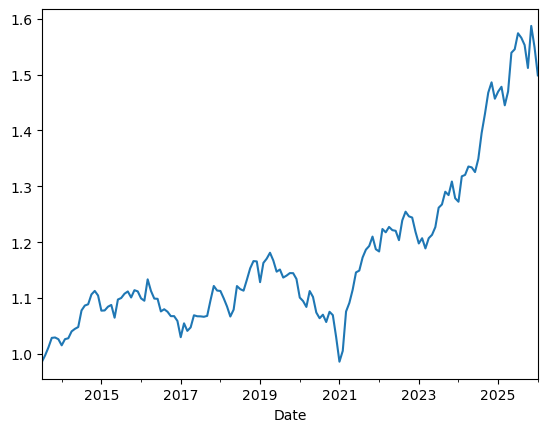

In [118]:
(1+hedged_df['HEDGED_RET']).cumprod().plot()

---
#### **Rolling ASVI**

In [120]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

def make_month_dummies(index: pd.DatetimeIndex, drop_first=True, add_const=True):
    month = index.month
    dummies = pd.get_dummies(month, prefix="m", drop_first=drop_first).astype(float)
    dummies.index = index
    if add_const:
        dummies = sm.add_constant(dummies, has_constant='add')
    return dummies

In [121]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

def compute_asvi_oos(
    ln_SVI: pd.DataFrame,
    X: pd.DataFrame,
    window: int = 60,          # rolling일 때 윈도우
    method: str = "rolling",   # "rolling" or "expanding"
    min_obs: int = 36,         # 최소 추정 표본
) -> pd.DataFrame:
    """
    선견편향 없는 ASVI(계절조정 잔차)를 시점별로 생성.
    각 t에서 t 이전 데이터만 사용해 OLS 적합 -> t의 잔차(residual_t)만 기록.

    ln_SVI: index=DatetimeIndex, columns=키워드들, values=로그SVI(또는 로그차분 등)
    X:      index=DatetimeIndex, 계절성/통제변수(상수 포함 권장)
    """
    if not ln_SVI.index.equals(X.index):
        # 공통 인덱스로 정렬
        common = ln_SVI.index.intersection(X.index)
        ln_SVI = ln_SVI.loc[common].sort_index()
        X = X.loc[common].sort_index()

    ASVI = pd.DataFrame(index=ln_SVI.index, columns=ln_SVI.columns, dtype=float)

    for col in ln_SVI.columns:
        y_all = ln_SVI[col].astype(float)

        for i, t in enumerate(ln_SVI.index):
            # t시점 ASVI는 "t 이전 데이터"로만 추정
            end = i  # use [0:end) so it ends at t-1
            if end < min_obs:
                continue

            if method == "rolling":
                start = max(0, end - window)
            elif method == "expanding":
                start = 0
            else:
                raise ValueError("method must be 'rolling' or 'expanding'")

            y_win = y_all.iloc[start:end]
            X_win = X.iloc[start:end]

            # 윈도우 내 결측 제거
            mask = y_win.notna() & X_win.notna().all(axis=1)
            if mask.sum() < min_obs:
                continue

            model = sm.OLS(y_win.loc[mask], X_win.loc[mask]).fit()

            # t 시점의 '예측오차(잔차)' = y_t - X_t * beta_hat
            y_t = y_all.iloc[i]
            X_t = X.iloc[i]

            if pd.isna(y_t) or X_t.isna().any():
                continue

            y_hat_t = float(np.dot(X_t.to_numpy(), model.params.to_numpy()))
            ASVI.iloc[i, ASVI.columns.get_loc(col)] = y_t - y_hat_t

    return ASVI

In [186]:
# 예: 월더미로 계절성 제거(상수 포함)
X = make_month_dummies(ln_SVI.index, drop_first=True, add_const=True)

# rolling 60개월로 OOS ASVI 생성
ASVI_oos = compute_asvi_oos(
    ln_SVI=ln_SVI,
    X=X,
    window=36,
    method="rolling",   # or "expanding"
    min_obs=36
)

ASVI_oos = ASVI_oos.dropna()
ASVI_oos.tail()

,N_배당,N_배당금,N_배당_주제_1,N_배당_주제_2,G_배당,G_배당금
Date,,,,,,
2025-09-30,-0.281583,0.051314,-0.061102,0.024427,-0.041541,0.110965
2025-10-31,-0.139979,0.064749,-0.014752,0.081004,0.191287,0.172519
2025-11-30,0.357888,-0.197686,0.002374,-0.115228,0.308486,0.071646
2025-12-31,-0.431548,-0.108525,-0.223872,-0.289492,-0.009837,-0.091456
2026-01-31,0.093613,0.157256,0.142589,0.269897,-0.124108,-0.126549


In [187]:
ASVI_oos.tail()

,N_배당,N_배당금,N_배당_주제_1,N_배당_주제_2,G_배당,G_배당금
Date,,,,,,
2025-09-30,-0.281583,0.051314,-0.061102,0.024427,-0.041541,0.110965
2025-10-31,-0.139979,0.064749,-0.014752,0.081004,0.191287,0.172519
2025-11-30,0.357888,-0.197686,0.002374,-0.115228,0.308486,0.071646
2025-12-31,-0.431548,-0.108525,-0.223872,-0.289492,-0.009837,-0.091456
2026-01-31,0.093613,0.157256,0.142589,0.269897,-0.124108,-0.126549


---
#### **타이밍 거래**

In [219]:
import pandas as pd
import numpy as np

def sign_timing_strategy(
    signal: pd.Series,
    rf: pd.Series,
    hedged_ret: pd.Series,
    *,
    lag: int = 1,
    rule: str = "neg_on",   # "neg_on" : signal<=0이면 ON(1), "pos_on": signal>0이면 ON(1)
) -> pd.DataFrame:
    """
    단순 방향(부호) 전략.

    입력
    - signal: ASVI 시계열 (예: ASVI_oos['N_배당_주제_1'])
    - rf: 무위험수익률(월) (예: factor['RF'])
    - hedged_ret: hedged_df['HEDGED_RET'] (총수익률 형태)

    전략(현금 + 알파 오버레이)
    - hedged_excess_t = hedged_ret_t - rf_t
    - STRAT_TOTAL_t = rf_t + w_{t-lag} * hedged_excess_t

    rule
    - "neg_on": (기본) signal_t <= 0 이면 다음달 ON(w=1), signal_t > 0 이면 OFF(w=0)
               (ASVI↑ -> 다음달 성과↓ 라는 네 결과에 맞는 방향)
    - "pos_on": signal_t > 0 이면 ON(w=1), 그 외 OFF(w=0)

    lag
    - lag=1: t에서 관측된 signal로 t+1 수익률에 적용(표준적)
    """
    # 공통 인덱스 정렬
    common = signal.index.intersection(rf.index).intersection(hedged_ret.index)
    s = signal.loc[common].astype(float).sort_index()
    rf_ = rf.loc[common].astype(float).sort_index()
    h = hedged_ret.loc[common].astype(float).sort_index()

    # 비중(w): 0/1
    if rule == "neg_on":
        w = (s <= 0).astype(float)   # <=0이면 ON(1)
    elif rule == "pos_on":
        w = (s > 0).astype(float)    # >0이면 ON(1)
    else:
        raise ValueError("rule must be 'neg_on' or 'pos_on'")

    # 다음달에 적용
    w_apply = w.shift(lag)

    # 알파(초과수익) 오버레이
    hedged_excess = h - rf_
    strat_total = rf_ + w_apply * hedged_excess
    strat_excess = strat_total - rf_

    out = pd.DataFrame(
        {
            "signal": s,
            "weight": w,
            f"weight_apply_lag{lag}": w_apply,
            "RF": rf_,
            "HEDGED_RET": h,
            "HEDGED_EXCESS": hedged_excess,
            "STRAT_TOTAL": strat_total,
            "STRAT_EXCESS": strat_excess,
        },
        index=common,
    )

    # 유효 구간(적용비중이 있는 구간)
    out["is_valid"] = out[f"weight_apply_lag{lag}"].notna() & out["STRAT_TOTAL"].notna()

    return out


# ===== 사용 예시 =====
# signal = ASVI_oos['N_배당_주제_1']
# rf = factor['RF']
# hedged_ret = hedged_df['HEDGED_RET']

signal = ASVI_oos['N_배당_주제_1']
rf = factor['RF']
hedged_ret = hedged_df['HEDGED_RET']

timed_sign = sign_timing_strategy(
    signal=signal,
    rf=rf,
    hedged_ret=hedged_df["HEDGED_RET"],
    lag=1,
    rule="neg_on"   # ASVI↑ -> 다음달 성과↓라면 이게 기본
)

timed_sign_clean = timed_sign.loc[timed_sign["is_valid"]].copy()

In [220]:
timed_sign_clean = timed_sign_clean.loc[:'2025-12-31']
timed_sign_clean['UNHEDGED_RET'] = ls_portfolio.loc[timed_sign_clean.index]
timed_sign_clean

,signal,weight,weight_apply_lag1,RF,HEDGED_RET,HEDGED_EXCESS,STRAT_TOTAL,STRAT_EXCESS,is_valid,UNHEDGED_RET
Date,,,,,,,,,,
2019-03-31,-0.080768,1.0,1.0,0.001570,0.006543,0.004973,0.006543,0.004973,True,0.002282
2019-04-30,0.140284,0.0,1.0,0.001521,0.009058,0.007537,0.009058,0.007537,True,0.038762
2019-05-31,-0.021155,1.0,0.0,0.001521,-0.011760,-0.013280,0.001521,0.000000,True,-0.038091
2019-06-30,-0.167655,1.0,1.0,0.001471,-0.017122,-0.018593,-0.017122,-0.018593,True,0.029537
2019-07-31,0.097884,0.0,1.0,0.001241,0.003367,0.002125,0.003367,0.002125,True,-0.057190
...,...,...,...,...,...,...,...,...,...,...
2025-08-31,-0.182374,1.0,0.0,0.002084,-0.005149,-0.007233,0.002084,0.000000,True,-0.020708
2025-09-30,-0.061102,1.0,1.0,0.002117,-0.008321,-0.010438,-0.008321,-0.010438,True,0.011185
2025-10-31,-0.014752,1.0,1.0,0.002101,-0.026424,-0.028524,-0.026424,-0.028524,True,0.001368


<Axes: xlabel='Date'>

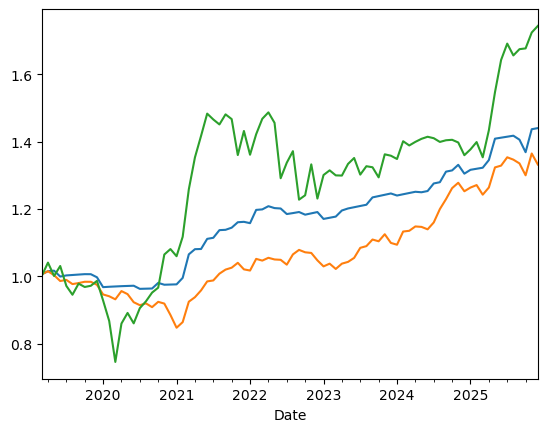

In [221]:
(1 + timed_sign_clean['STRAT_TOTAL']).cumprod().plot()
(1 + timed_sign_clean['HEDGED_RET']).cumprod().plot()
(1 + timed_sign_clean['UNHEDGED_RET']).cumprod().plot()

In [229]:
import numpy as np
import pandas as pd

def max_drawdown(returns: pd.Series) -> float:
    """월 수익률 시계열로부터 MDD 계산."""
    r = returns.dropna().astype(float)
    if r.empty:
        return np.nan
    equity = (1.0 + r).cumprod()
    peak = equity.cummax()
    dd = equity / peak - 1.0
    return float(dd.min())

def annualized_stats(returns: pd.Series, periods_per_year=12) -> dict:
    """연환산 수익률/변동성/샤프(무위험 0 가정), 월평균/t값/승률/MDD."""
    r = returns.dropna().astype(float)
    n = len(r)
    if n < 3:
        return {
            "n_months": n,
            "ann_return": np.nan,
            "ann_vol": np.nan,
            "sharpe": np.nan,
            "mean_month": np.nan,
            "t_mean": np.nan,
            "win_rate": np.nan,
            "mdd": np.nan,
        }

    mean_m = r.mean()
    vol_m = r.std(ddof=1)

    ann_ret = (1.0 + mean_m) ** periods_per_year - 1.0
    ann_vol = vol_m * np.sqrt(periods_per_year)
    sharpe = np.nan if ann_vol == 0 else ann_ret / ann_vol

    # 월평균 t-stat (독립/정규 가정의 단순 t; HAC 쓰려면 별도)
    t_mean = np.nan if vol_m == 0 else mean_m / (vol_m / np.sqrt(n))

    win_rate = (r > 0).mean()
    mdd = max_drawdown(r)

    return {
        "n_months": n,
        "ann_return": ann_ret,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "mean_month": mean_m,
        "t_mean": t_mean,
        "win_rate": win_rate,
        "mdd": mdd,
    }

def compare_strategies(timed_sign: pd.DataFrame) -> pd.DataFrame:
    """
    timed_sign에는 최소한 아래 컬럼이 있어야 함:
      - 'RF'
      - 'HEDGED_RET'
      - 'STRAT_TOTAL'
    """
    df = timed_sign.copy()

    # 유효구간만 자동 선택
    if "is_valid" in df.columns:
        df = df.loc[df["is_valid"]].copy()

    series_dict = {
        "UNHEDGED (UNHEDGED_RET)": df["UNHEDGED_RET"],
        "Always-on (HEDGED_RET)": df["HEDGED_RET"],
        "Timing (STRAT_TOTAL)": df["STRAT_TOTAL"],
    }

    rows = {}
    for name, ser in series_dict.items():
        rows[name] = annualized_stats(ser)

    out = pd.DataFrame(rows).T

    # 보기 좋게 퍼센트로 변환(선택)
    pct_cols = ["ann_return", "ann_vol", "mean_month", "mdd", "win_rate"]
    out_fmt = out.copy()
    for c in pct_cols:
        out_fmt[c] = out_fmt[c] * 100

    # 샤프, t는 그대로
    return out_fmt

# ===== 사용 예시 =====
# timed_sign_clean = timed_sign.loc[timed_sign["is_valid"]].copy()
summary_table = compare_strategies(timed_sign_clean)
print(summary_table.round(3))

                         n_months  ann_return  ann_vol  sharpe  mean_month  \
UNHEDGED (UNHEDGED_RET)      82.0       9.925   16.451   0.603       0.792   
Always-on (HEDGED_RET)       82.0       4.526    6.876   0.658       0.370   
Timing (STRAT_TOTAL)         82.0       5.610    5.006   1.121       0.456   

                         t_mean  win_rate     mdd  
UNHEDGED (UNHEDGED_RET)   1.510    60.976 -28.293  
Always-on (HEDGED_RET)    1.686    54.878 -16.512  
Timing (STRAT_TOTAL)      2.857    79.268  -5.299  


In [230]:
def cum_index(returns: pd.Series) -> pd.Series:
    r = returns.dropna().astype(float)
    return (1.0 + r).cumprod()

plot_df = timed_sign_clean.loc[timed_sign_clean["is_valid"], ["HEDGED_RET", "STRAT_TOTAL", "UNHEDGED_RET"]].copy()
cum_df = plot_df.apply(cum_index)
print(cum_df.tail())

            HEDGED_RET  STRAT_TOTAL  UNHEDGED_RET
Date                                             
2025-08-31    1.346552     1.417559      1.655692
2025-09-30    1.335348     1.405763      1.674211
2025-10-31    1.300063     1.368618      1.676502
2025-11-30    1.364800     1.436769      1.723615
2025-12-31    1.332060     1.440091      1.743165


<Axes: xlabel='Date'>

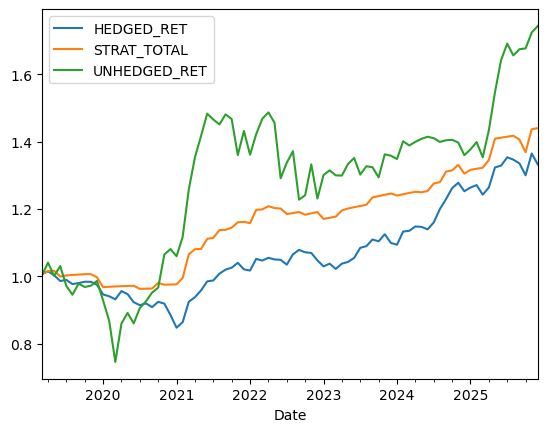

In [231]:
cum_df.plot()

##### **연구 설계 및 실증 결과 정리**

**1. 팩터-헤지된 거래가능 알파 계산**

고배당 포트폴리오 수익률에서 Carhart 4요인 노출을 제거하여
거래가능한 순수 알파를 다음과 같이 정의한다.

$$
r^{hedge}_{t+1}
=
r^{HD}_{t+1}
-\hat{\beta}_{M,t} MKT_{t+1}
-\hat{\beta}_{S,t} SMB_{t+1}
-\hat{\beta}_{H,t} HML_{t+1}
-\hat{\beta}_{U,t} MOM_{t+1}
$$


**2. 36개월 Rolling 회귀 기반 계절조정 ASVI 계산**

- 36개월 rolling window 회귀를 통해 ASVI의 계절성을 제거
- 잔차(residual)를 계절조정된 ASVI로 정의
- 이를 시점 t의 투자 시그널로 활용


**3. ASVI 기반 타이밍 포트폴리오 구축**

- ASVI_t > 0  → 익월 팩터-헤지 알파 100% 투자
- ASVI_t ≤ 0 → 무위험자산 100% 투자
- 즉, 가중치 (1, 0) 구조의 단순 타이밍 전략


**4. 성과 비교**

| Strategy | n_months | Ann.Return (%) | Ann.Vol (%) | Sharpe | Mean.Month (%) | t-stat | Win Rate (%) | MDD (%) |
|----------|----------|----------------|-------------|--------|----------------|--------|--------------|---------|
| UNHEDGED (UNHEDGED_RET) | 82 | 9.925 | 16.451 | 0.603 | 0.792 | 1.510 | 60.976 | -28.293 |
| Always-on (HEDGED_RET)  | 82 | 4.526 | 6.876  | 0.658 | 0.370 | 1.686 | 54.878 | -16.512 |
| Timing (STRAT_TOTAL)    | 82 | 5.610 | 5.006  | **1.121** | 0.456 | **2.857** | **79.268** | **-5.299** |


**해석**

- 단순 팩터 제거(Always-on)만으로도 변동성과 MDD는 크게 감소
- ASVI 타이밍 전략은 Sharpe ratio와 t-stat이 가장 우수
- 특히 MDD가 -5.3% 수준으로 크게 개선됨
- 정보지표(ASVI)가 팩터-중립 알파의 조건부 기대수익을 예측할 가능성 시사

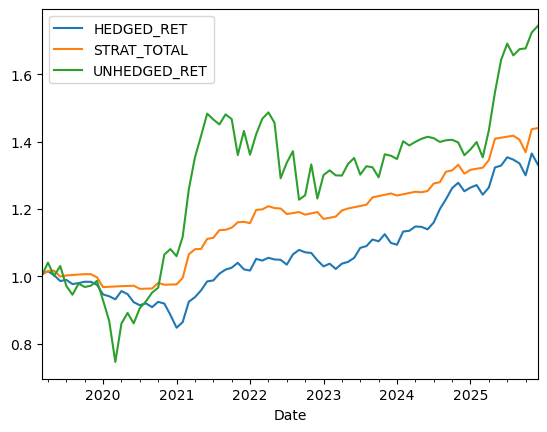